In [1]:
network_data = 'nets/init_siren/mod5.pt'
time = 30
step =1

In [2]:
import torch
import numpy as np

import Modules.preprocess as pp
import re
#This defines where the data is
data  = torch.load('../../data/data.pt', weights_only=True)
# nums = re.findall(r'\d+', network_data)  
# first, second = map(int, nums[:2]) 
frames = np.arange(300, 322, step=step)
from Modules.Neural_Net import Net


    

train_beams = list(range(0, 32))
model = torch.load(network_data, weights_only = False)

# #This generates the data
# train_data = pp.data_gen(data, beams = train_beams, frames=frames, normalize=model['scalers'], splits =.99)
# train_dataloader, q  = train_data.get_dataloaders(train_data, batch_size=1, num_workers=4)

#This makes the model


net = Net(model['act'], *model['model config'], siren = False).to('cpu')
net.load_state_dict(model['model_state_dict'])
net.eval()
print('done')

done


In [3]:
_1 = 29.
_2 = 3.

frame = data[300]
mask = (frame[:, 3] == torch.tensor(_1)) + (frame[:, 3] == torch.tensor(_2))
frame = frame[mask]

x1 = frame[:, 0]
y1 = frame[:, 1]

frame = data[310]
mask = (frame[:, 3] == torch.tensor(_1)) + (frame[:, 3] == torch.tensor(_2))
frame = frame[mask]

x2 = frame[:, 0]
y2 = frame[:, 1]

frame = data[320]
mask = (frame[:, 3] == torch.tensor(_1)) + (frame[:, 3] == torch.tensor(_2))
frame = frame[mask]

x3 = frame[:, 0]
y3 = frame[:, 1]

In [4]:
from Modules.evaluate import Evaluator
from Modules.evaluate import pick_data

time = [30, 31, 32]

def add_t(tensor, time):
    return torch.cat([tensor, torch.ones_like(tensor[:, 0]).unsqueeze(1)*time], dim=1).to(dtype=torch.float32)

heights = []
for t in time:
    # inputs = torch.load('Modules/plotting_region.pt', weights_only = True)
    # inputs = add_t(inputs,t)

    y = torch.arange(-180, -146, .1)
    x = torch.arange(-230, -180, .1)
    X, Y = torch.meshgrid((x, y) , indexing = 'ij')
    x = X.flatten().reshape(-1, 1)
    y = Y.flatten().reshape(-1, 1)
    xy = torch.hstack([x, y])
    xyt = add_t(xy, time = t)

    evaluator = Evaluator(net, scalers = model['scalers'], inputs=xyt)
    pred_z, scaled_pred = evaluator.net_eval()
    heights.append(pred_z)


raw = pick_data(data=data, beams= train_beams, frames =frames)
raw_in0, raw_out0 = raw.data_out_numpy(time[0])
rx0, ry0, rz0 = [raw_in0[:,0], raw_in0[:,1], raw_out0]

raw_in1, raw_out1 = raw.data_out_numpy(time[1])
rx1, ry1, rz1 = [raw_in1[:,0], raw_in1[:,1], raw_out1]

raw_in2, raw_out2 = raw.data_out_numpy(time[2])
rx2, ry2, rz2 = [raw_in2[:,0], raw_in2[:,1], raw_out2]


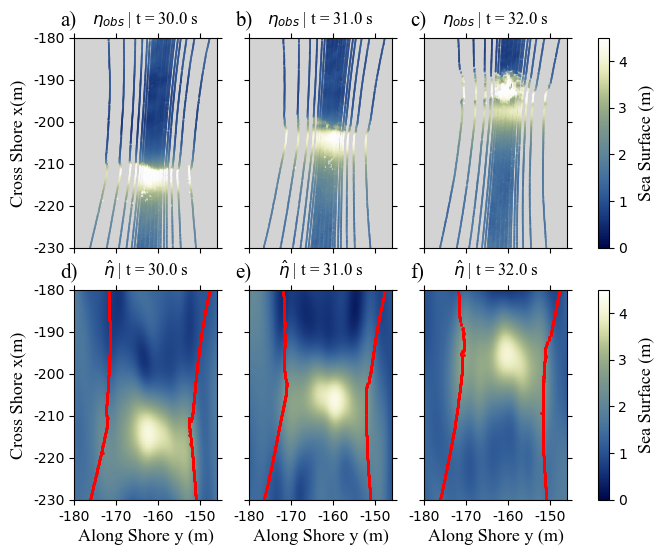

In [5]:
# Make the pretty plot 
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
vmax =4.5
#Make the plot

fig,axes  = plt.subplots(2,3, figsize=(8, 6))
[(d0, d1, d2), (nn0, nn1, nn2)] = axes

for ax in axes.flat:
    ax.tick_params(top=True, right=True, bottom=True, left=True)



# Reconstruct 2D grid for pcolormesh (same grid used during evaluation)
x_1d = torch.arange(-230, -180, .1)
y_1d = torch.arange(-180, -146, .1)
X_grid, Y_grid = torch.meshgrid(x_1d, y_1d, indexing='ij')
grid_shape = X_grid.shape

# NN rows: pcolormesh (draws the continuous field)
mesh_handles = []
for i, ax in enumerate(axes[1]):
    Z = heights[i]
    if hasattr(Z, 'detach'):
        Z = Z.detach().numpy()
    else:
        Z = np.array(Z)
    mesh = ax.pcolormesh(Y_grid.numpy(), X_grid.numpy(), Z.reshape(grid_shape),
                         vmin=0, vmax=vmax, cmap=cmc.davos)
    mesh_handles.append(mesh)

scat0 = d0.scatter(ry0, rx0, c = rz0, vmin=0, vmax=vmax, cmap=cmc.davos, s =.1)
scat1 = d1.scatter(ry1, rx1, c = rz1, vmin=0, vmax=vmax, cmap=cmc.davos, s =.1)
scat2 = d2.scatter(ry2, rx2, c = rz2, vmin=0, vmax=vmax, cmap=cmc.davos, s =.1)


for ax in axes[0]:
    ax.set_aspect('equal')
    ax.set_facecolor('lightgray')
    ax.set_ylim(-230, -180)
    ax.set_xlim(-180, -146)
    ax.set_xticks([ -180, -170,  -160,   -150])
    ax.set_xticklabels([])
    ax.set_yticklabels([])

for ax in axes[1]:
    ax.set_aspect('equal')
    ax.set_ylim(-230, -180)
    ax.set_xlim(-180, -146)
    ax.set_xticks([ -180, -170,  -160,   -150])
    ax.set_xticklabels([ -180, -170, -160, -150])
    ax.set_yticklabels([])
    ax.set_xlabel('Along Shore y (m)', font= 'Times New Roman', fontsize = 13)

d0.set_yticks([-230, -220, -210, -200, -190, -180])
d0.set_yticklabels([-230, -220, -210, -200, -190, -180])
nn0.set_yticks([-230, -220, -210, -200, -190, -180])
nn0.set_yticklabels([-230, -220, -210, -200, -190, -180])



d0.set_ylabel('Cross Shore x(m)', font= 'Times New Roman', fontsize = 13, labelpad=5)  
nn0.set_ylabel('Cross Shore x(m)', font= 'Times New Roman', fontsize = 13, labelpad=5)    

fs0 = 12
d0.set_title(r'$\eta_{obs}$ | t = 30.0 s', font= 'Times New Roman', fontsize = fs0, pad = 10 )
d1.set_title(r'$\eta_{obs}$ | t = 31.0 s', font= 'Times New Roman', fontsize = fs0, pad = 10 )
d2.set_title(r'$\eta_{obs}$ | t = 32.0 s', font= 'Times New Roman', fontsize = fs0, pad = 10 )

nn0.set_title(r'$\hat{\eta}$ | t = 30.0 s', font= 'Times New Roman', fontsize = fs0, pad = 10 )
nn1.set_title(r'$\hat{\eta}$ | t = 31.0 s', font= 'Times New Roman', fontsize = fs0, pad = 10 )
nn2.set_title(r'$\hat{\eta}$ | t = 32.0 s', font= 'Times New Roman', fontsize = fs0, pad = 10 )

nn0.scatter(y1, x1, c = 'red', s = 1)
nn1.scatter(y2, x2, c = 'red', s = 1)
nn2.scatter(y3, x3, c = 'red', s = 1)


dc = fig.colorbar(scat2, ax=[d0, d1, d2], location='right', pad=0.05, shrink=1)
dc.set_label('Sea Surface (m)', font= 'Times New Roman', labelpad=8, fontsize = 13)

nnc = fig.colorbar(scat2, ax=[nn0, nn1, nn2], location='right', pad=0.05, shrink=1)
nnc.set_label('Sea Surface (m)', font= 'Times New Roman', labelpad=8, fontsize = 13)

pad = 1.13

fs1 =15

d0.text(-.1, pad, 'a)', transform=d0.transAxes, va='top', ha='left', fontsize=fs1, font = 'Times New Roman')
d1.text(-.1, pad, 'b)', transform=d1.transAxes, va='top', ha='left', fontsize=fs1, font = 'Times New Roman')
d2.text(-.1, pad, 'c)', transform=d2.transAxes, va='top', ha='left', fontsize=fs1, font = 'Times New Roman')

nn0.text(-.1, pad, 'd)', transform=nn0.transAxes, va='top', ha='left', fontsize=fs1, font = 'Times New Roman')
nn1.text(-.1, pad, 'e)', transform=nn1.transAxes, va='top', ha='left', fontsize=fs1, font = 'Times New Roman')
nn2.text(-.1, pad, 'f)', transform=nn2.transAxes, va='top', ha='left', fontsize=fs1, font = 'Times New Roman')

# plt.savefig('../../overleaf/figures/nn_v_data.pdf')
# plt.savefig('../../overleaf/figures/nn_v_data.png', dpi= 300)
# plt.savefig('nn_v_data.png', dpi= 300)
plt.show()
plt.close()

In [2]:
from Modules.Neural_Net import Net
import torch

model1 = torch.load('nets/init_siren/mod3.pt')
model2 = torch.load('nets/init_siren/mod4.pt')


w_0 = model1['w_0']
def sine(x):
    return torch.sin(w_0*x)

net1 = Net(sine, *model1['model config'])
net2 = Net(sine, *model2['model config'])

net1.load_state_dict(model1['model_state_dict'])
net2.load_state_dict(model2['model_state_dict'])

C:\Users\dculv\AppData\Local\Temp\ipykernel_21440\3916923371.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model1 = torch.load('nets/init_siren/mod3.pt')
C:\Users\dcul

<All keys matched successfully>

In [5]:
from Modules.evaluate import Evaluator
import numpy as np


def add_t(tensor, time):
    return torch.cat([tensor, torch.ones_like(tensor[:, 0]).unsqueeze(1)*time], dim=1).to(dtype=torch.float32)


with torch.no_grad():
    y = torch.arange(-180, -146, .1)
    x = torch.arange(-230, -180, .1)
    X, Y = torch.meshgrid((x, y) , indexing = 'ij')
    w1 = X.flatten().reshape(-1, 1)
    w2 = Y.flatten().reshape(-1, 1)
    xy = torch.hstack([w1, w2])
    xyt = add_t(xy, time = 30.0)
    eval1 = Evaluator(net = net1, scalers = model1['scalers'], inputs= xyt)
    eval2 = Evaluator(net = net2, scalers = model2['scalers'], inputs= xyt)

    z = eval2.net_eval()[0].numpy() - eval1.net_eval()[0].numpy()
    z_2d = np.abs(z.reshape(x.shape[0], y.shape[0]))
    x = xy[:, 0].numpy().reshape(-1,1)
    y = xy[:, 1].numpy().reshape(-1,1)

mask =(np.abs(z) == np.abs(z).max())

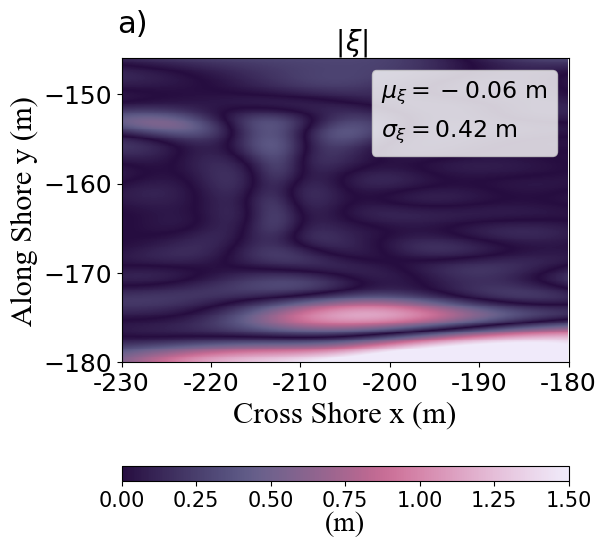

In [6]:
import matplotlib.pyplot as plt
import cmcrameri.cm as cmc
import matplotlib.colors  as colors
from matplotlib.lines import Line2D



font = 'Times New Roman'
fs = 22

fig, ax2 = plt.subplots(1, 1, figsize=(6, 6))

im2 = ax2.pcolormesh(X, Y, z_2d, cmap=cmc.acton, vmin=0, vmax=1.5,
                 )

cbar2 = fig.colorbar(im2, ax=ax2, aspect=30, fraction=.15, orientation='horizontal', pad = .2)
cbar2.set_label('(m)',  rotation=0, labelpad=0, fontsize =20, fontname = 'Times New Roman')
cbar2.ax.tick_params(labelsize = 15)


ax2.set_aspect('equal')
ax2.set_xlim(-230, -180)
ax2.set_ylim(-180, -146)
ax2.set_xlabel('Cross Shore x (m)',fontsize=fs, font = font )
ax2.set_ylabel('Along Shore y (m)',fontsize=fs, font = font )
ax2.set_title(r'  $|\xi|$', fontsize=20, fontname='Times New Roman' )

ax2.set_xticks([-230, -220, -210, -200, -190, -180])
ax2.set_xticklabels([-230, -220, -210, -200, -190, -180])

ax2.set_ylim(-180, -146)
ax2.set_yticks([ -180, -170,  -160,   -150])


e2 = [z.mean(), z.std()]
h2 = [
        Line2D([], [], color='none', label=rf'$\mu_\xi = {-1*e2[0]:.2f}$ m'),
        Line2D([], [], color='none', label=rf'$\sigma_\xi = {e2[1]:.2f}$ m'),
    ]
ax2.legend(handles=h2, loc='upper right', handlelength=0, 
              handletextpad=0, fontsize=17)

ax2.text(-0.01, 1.16, 'a)', transform=ax2.transAxes, va='top', ha='left', fontsize=fs, )

ax2.tick_params(axis = 'both', labelsize = 18)


plt.tight_layout()
plt.show()

(17635, 3)


C:\Users\dculv\AppData\Local\Temp\ipykernel_15680\116273956.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model1 = torch.load('nets/init_siren/mod1.pt')
C:\Users\dcul

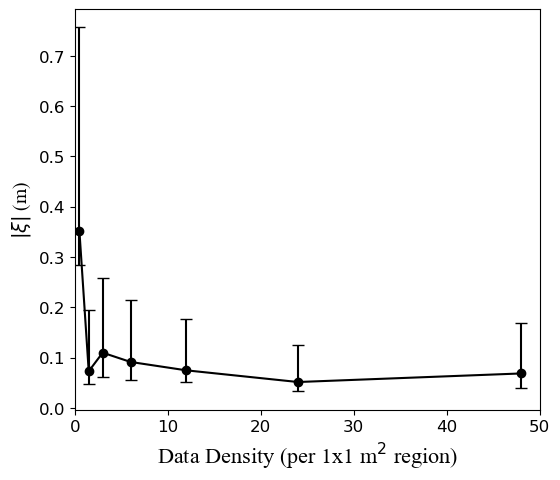

In [1]:
from Modules.evaluate import pick_data
import numpy as np
import torch


step =1

train_beams = list(range(0, 32))
frames = np.arange(300, 320, step=step)
data  = torch.load('../../data/data.pt', weights_only=True)


raw = pick_data(data=data, beams= train_beams, frames =frames)
raw_in, raw_out = raw.data_out_numpy(30)
print(raw_in.shape)
raw_x = raw_in[:,0]
raw_y = raw_in[:,1]
raw_z = raw_out
from Modules.Neural_Net import Net

model1 = torch.load('nets/init_siren/mod1.pt')
model2 = torch.load('nets/init_siren/mod2.pt')

w_0 = model1['w_0']
def sine(x):
    return torch.sin(w_0*x)

net1 = Net(sine, *model1['model config'])
net2 = Net(sine, *model2['model config'])

net1.load_state_dict(model1['model_state_dict'])
net2.load_state_dict(model2['model_state_dict'])

from Modules.evaluate import Evaluator


def add_t(tensor, time):
    return torch.cat([tensor, torch.ones_like(tensor[:, 0]).unsqueeze(1)*time], dim=1).to(dtype=torch.float32)


with torch.no_grad():
    y = torch.arange(-180, -146, .1)
    x = torch.arange(-230, -180, .1)
    X, Y = torch.meshgrid((x, y) , indexing = 'ij')
    w1 = X.flatten().reshape(-1, 1)
    w2 = Y.flatten().reshape(-1, 1)
    xy = torch.hstack([w1, w2])
    xyt = add_t(xy, time = 30.0)
    eval1 = Evaluator(net = net1, scalers = model1['scalers'], inputs= xyt)
    eval2 = Evaluator(net = net2, scalers = model2['scalers'], inputs= xyt)

    z = eval2.net_eval()[0].numpy() - eval1.net_eval()[0].numpy()
    z_2d = z.reshape(x.shape[0], y.shape[0])
    x = xy[:, 0].numpy().reshape(-1,1)
    y = xy[:, 1].numpy().reshape(-1,1)
import numpy as np


x_edges = np.arange(-230, -180 + 2, 1)
y_edges = np.arange(-180, -146 + 2, 1)

H, xedges, yedges = np.histogram2d(raw_x, raw_y, bins=[x_edges, y_edges], density=False)
ix = np.digitize(x.ravel(), xedges) - 1
iy = np.digitize(y.ravel(), yedges) - 1

ix = np.clip(ix, 0, H.shape[0] - 1)
iy = np.clip(iy, 0, H.shape[1] - 1)

density = H[ix, iy] 
abz = np.abs(z.ravel())
bins = []
hist =[]

den = 0
newden = .1
i=0
while den < density.max():
    if i == 0:
        den = 0
        newden = .5

        mask = (density >= den)&(density< newden)
        binz = abz[mask]
        hist.append(binz.shape[0])
        if binz.size > 0:
            bins.append(np.array([.5, binz.mean(), *np.quantile(binz, [0.25, 0.75]), len(binz)]))
        den =1
        newden =2
        i+=1
    if i>0:
        mask = (density >= den)&(density< newden)
        binz = abz[mask]
        hist.append(binz.shape[0])
        if binz.size > 0:
            bins.append(np.array([(newden-den)/2+den, binz.mean(), *np.quantile(binz, [0.25, 0.75]), len(binz)]))
        den = den*2
        newden = newden*2


bins = np.array(bins)
bins.shape

bins[:, 0]
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


fig, ax = plt.subplots(1,1, figsize = (6, 5.2))

gs = gridspec.GridSpec(2, 2, width_ratios=[1.5, 1], figure=fig)


ax.errorbar(bins[:,0], bins[:, 1], fmt = 'o', yerr = bins[:, 2:4].T, 
             capsize = 4 , ecolor= 'black', c = 'k')
ax.plot(bins[:, 0], bins[:, 1], color = 'black')

ax.set_xlabel('Data Density (per 1x1 m$^2$ region)', fontname = 'Times New Roman', fontsize = 16)
ax.set_ylabel(r'$|\xi|$ (m)', fontname = 'Times New Roman', fontsize = 14)

ax.set_xlim(0, 50)
ax.tick_params(labelsize = 12)


plt.show()